Average Evaluation Metrics across folds:
MSE: 0.0044
MAE: 0.0510
RMSE: 0.0661
R2: 0.0689


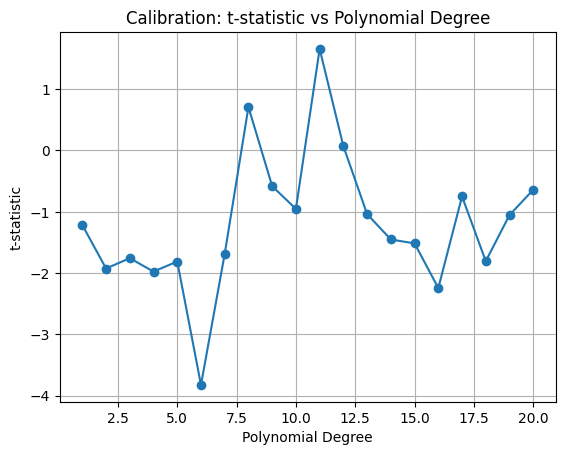

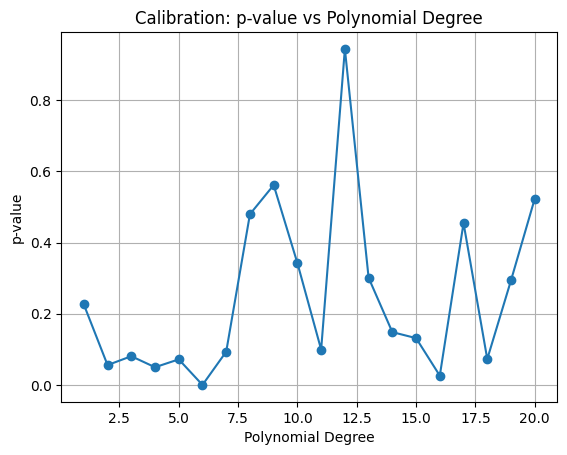

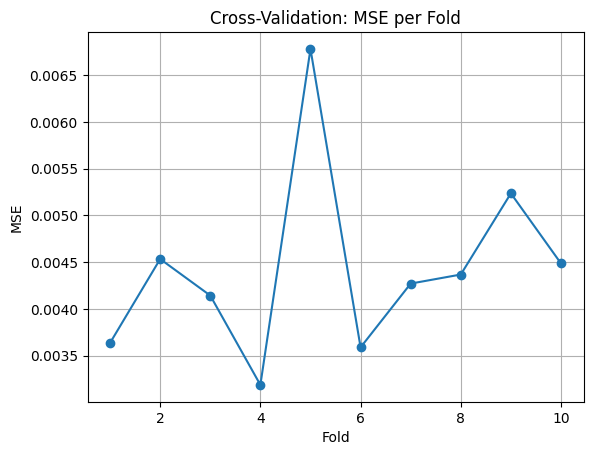

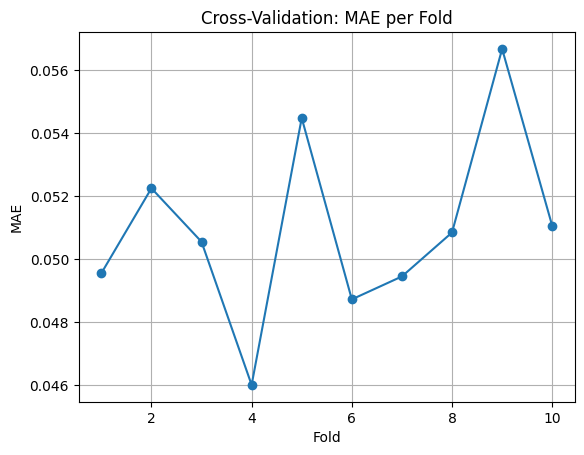

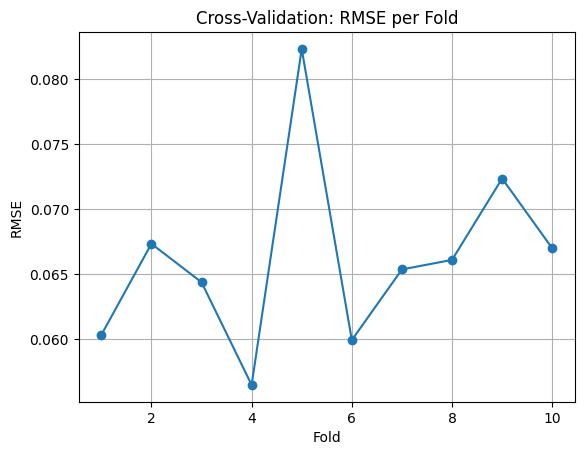

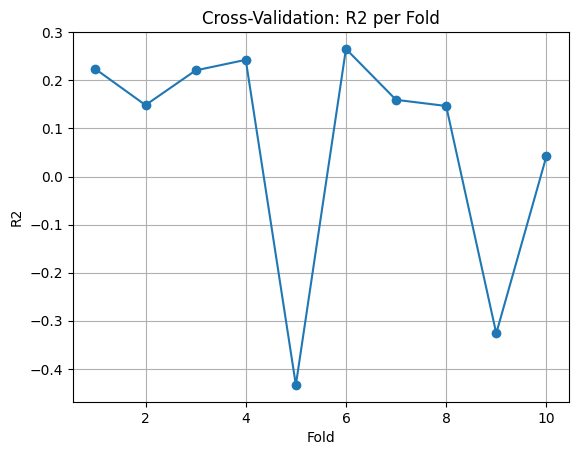

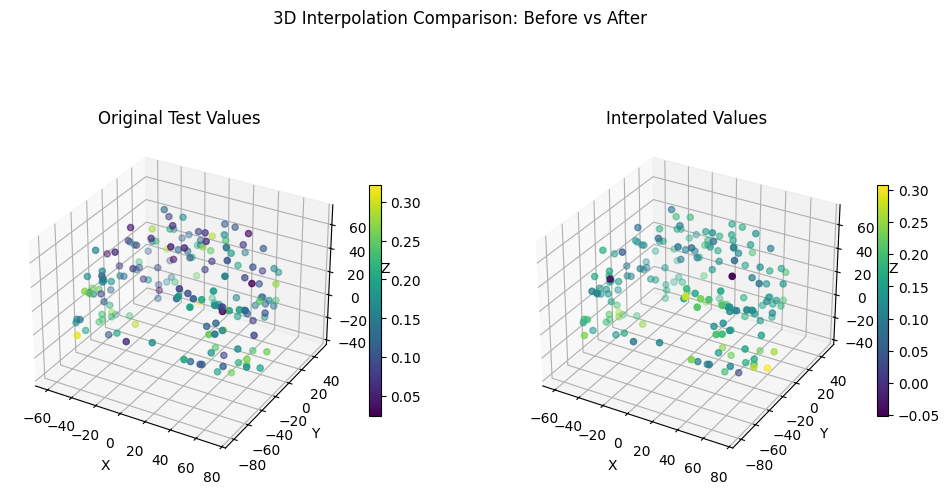

In [8]:
#import your packages
import os
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import ttest_rel
from numpy.polynomial import chebyshev as T
from mpl_toolkits.mplot3d import Axes3D  # for 3D visualization

#load in the dataset
# Loading the coordinates from the .npy file with shape [1772, 3]
# 1772 xyz coordinates
file_path = '/content'

coords_path = os.path.join(file_path, 'coords.npy')
coords = np.load(coords_path)

#load in band power dataset
band_powers_path = os.path.join(file_path, 'band_powers.npy')
band_powers = np.load(band_powers_path, allow_pickle=True).item()

band = 'Delta'
band_values = np.array(band_powers[band])

# --- New function: Build Design Matrix ---
def build_design_matrix(coords, degree, mins, maxs):
    """
    Build the design matrix using tensor product basis functions of Chebyshev polynomials
    based on normalized coordinates.

    Parameters:
    - coords: Array of coordinates, shape (n_points, 3)
    - degree: Polynomial degree (for each dimension)
    - mins: Minimum values for each dimension (shape: (3,))
    - maxs: Maximum values for each dimension (shape: (3,))

    Returns:
    - A: The design matrix, shape (n_points, (degree+1)^3)
    """
    n = coords.shape[0]
    A = np.zeros((n, (degree+1)**3))
    for i in range(n):
        # Normalize the three coordinates to the range [-1, 1]
        norm_pt = 2*(coords[i] - mins) / (maxs - mins) - 1
        # Compute Chebyshev basis for x, y, and z dimensions (resulting shape: (degree+1,))
        v_x = T.chebvander(norm_pt[0], degree)[0]
        v_y = T.chebvander(norm_pt[1], degree)[0]
        v_z = T.chebvander(norm_pt[2], degree)[0]
        # Construct the 3D basis using the Kronecker product (tensor product form)
        A[i, :] = np.kron(np.kron(v_x, v_y), v_z)
    return A

# --- Modified 3D Chebyshev Polynomial Interpolation ---
def interpolate(coords, values, new_coords, degree=5):
    """
    Fit and predict using 3D Chebyshev polynomial interpolation.

    Parameters:
    - coords: Original coordinates, shape (n_points, 3)
    - values: Corresponding values, shape (n_points,)
    - new_coords: Coordinates where predictions are needed, shape (m_points, 3)
    - degree: Polynomial degree (default is 5)

    Returns:
    - predicted_values: Interpolated results at new_coords
    """
    # Compute the minimum and maximum for each dimension from the training data for normalization
    mins = np.min(coords, axis=0)
    maxs = np.max(coords, axis=0)

    # Build the design matrix for the training set and solve for the polynomial coefficients
    A_train = build_design_matrix(coords, degree, mins, maxs)
    coeffs = np.linalg.lstsq(A_train, values, rcond=None)[0]

    # Build the design matrix for the prediction points and compute predictions
    A_new = build_design_matrix(new_coords, degree, mins, maxs)
    predicted_values = A_new.dot(coeffs)
    return predicted_values

# --- Modified chebyshev_interpolate_with_degree: directly calls interpolate ---
def chebyshev_interpolate_with_degree(coords, values, new_coords, degree):
    return interpolate(coords, values, new_coords, degree)

def your_function(coords, values, new_coords, timing=False):
    """
    Interpolates values at new coordinates using a chosen method.

    Parameters:
    - coords (array): Original coordinates.
    - values (array): Corresponding values at original coordinates.
    - new_coords (array): Coordinates where interpolation is performed.
    - timing (bool): If True, returns the interpolation duration.

    Returns:
    - predicted_values (array): Interpolated values at new_coords.
    - duration (float, optional): Time taken for interpolation (if timing=True).
    """
    start_time = time.time()  # Start timing

    # Use the 3D interpolation method
    predicted_values = interpolate(coords, values, new_coords)

    duration = time.time() - start_time  # Compute duration

    return (predicted_values, duration) if timing else predicted_values

def calculate_metrics(pred_values, test_values, metrics=None):
    """
    Computes error metrics to evaluate interpolation performance.

    Parameters:
    - pred_values (array): Predicted values from interpolation.
    - test_values (array): Ground truth values for comparison.
    - metrics (list, optional): List of metric names to compute.

    Returns:
    - scores (dict): Computed metric scores.
    """
    mse = mean_squared_error(test_values, pred_values)
    mae = mean_absolute_error(test_values, pred_values)
    rmse = np.sqrt(mse)
    r2 = r2_score(test_values, pred_values)
    scores = {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'R2': r2}
    return scores

# Define metrics to evaluate interpolation (now four metrics: MSE, MAE, RMSE and R2)
metrics = ['MSE', 'MAE', 'RMSE', 'R2']

# Initialize lists to store results
num_folds = 10
metric_results = []  # list of dicts for each fold
timings = np.zeros((num_folds))

# Use KFold to split the dataset in a 9:1 ratio (10 folds: 90% train, 10% test)
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# For visualization later, we will store the last fold's test set and interpolation results
visual_test_coords = None
visual_test_values = None
visual_pred_values = None

# Perform k-fold cross-validation
fold = 0
for train_index, test_index in kf.split(coords):
    train_values, train_coords = band_values[train_index], coords[train_index]
    test_values, test_coords = band_values[test_index], coords[test_index]

    # Run interpolation and measure execution time
    pred_values, duration = your_function(train_coords, train_values, test_coords, timing=True)
    timings[fold] = duration

    # Compute evaluation metrics using MSE, MAE, RMSE and R2
    fold_metrics = calculate_metrics(pred_values, test_values, metrics=metrics)
    metric_results.append(fold_metrics)

    # Store the last fold for 3D visualization
    visual_test_coords = test_coords
    visual_test_values = test_values
    visual_pred_values = pred_values

    fold += 1

# Compute average metrics across folds and print them
avg_metrics = {key: np.mean([fold_res[key] for fold_res in metric_results]) for key in metrics}
print("Average Evaluation Metrics across folds:")
for key, value in avg_metrics.items():
    print(f"{key}: {value:.4f}")

# If calibrating, add an extra loop for hyperparameter tuning
# Example: for polynomial_degree in range(1, 21):

# Visualization: Plot stored metrics (y-axis) against interpolation setups (x-axis, e.g., polynomial degree)
# Add appropriate visualization code here if needed
# For the project, each team member should produce 2 sets of plots:
# 1. Internal calibration experiments to figure out the best version of their model
# 2. Comparing the different models that have been implemented

# --- Set 1: Internal calibration experiments (tuning polynomial degree) ---
degrees = np.arange(1, 21)
calib_t_stats = []
calib_p_values = []

# Use the first fold from KFold as the calibration split
kf_calib = KFold(n_splits=10, shuffle=True, random_state=42)
for train_index, test_index in kf_calib.split(coords):
    train_coords_calib, train_values_calib = coords[train_index], band_values[train_index]
    test_coords_calib, test_values_calib = coords[test_index], band_values[test_index]
    break  # Use only the first split for calibration

for d in degrees:
    pred_vals = chebyshev_interpolate_with_degree(train_coords_calib, train_values_calib, test_coords_calib, d)
    t_stat, p_val = ttest_rel(test_values_calib, pred_vals)
    calib_t_stats.append(t_stat)
    calib_p_values.append(p_val)

# Plot calibration experiment results for t-statistic
plt.figure()
plt.plot(degrees, calib_t_stats, marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('t-statistic')
plt.title('Calibration: t-statistic vs Polynomial Degree')
plt.grid(True)
plt.show()

# Plot calibration experiment results for p-value
plt.figure()
plt.plot(degrees, calib_p_values, marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('p-value')
plt.title('Calibration: p-value vs Polynomial Degree')
plt.grid(True)
plt.show()

# --- Set 2: Comparing the different models (using cross-validation results) ---
# Our cross-validation results (using a fixed degree of 5 in our interpolation) are stored in metric_results.
cv_mse = [fold_res['MSE'] for fold_res in metric_results]
cv_mae = [fold_res['MAE'] for fold_res in metric_results]
cv_rmse = [fold_res['RMSE'] for fold_res in metric_results]
cv_r2 = [fold_res['R2'] for fold_res in metric_results]
folds = np.arange(1, num_folds + 1)

# Plot cross-validation MSE per fold
plt.figure()
plt.plot(folds, cv_mse, marker='o')
plt.xlabel('Fold')
plt.ylabel('MSE')
plt.title('Cross-Validation: MSE per Fold')
plt.grid(True)
plt.show()

# Plot cross-validation MAE per fold
plt.figure()
plt.plot(folds, cv_mae, marker='o')
plt.xlabel('Fold')
plt.ylabel('MAE')
plt.title('Cross-Validation: MAE per Fold')
plt.grid(True)
plt.show()

# Plot cross-validation RMSE per fold
plt.figure()
plt.plot(folds, cv_rmse, marker='o')
plt.xlabel('Fold')
plt.ylabel('RMSE')
plt.title('Cross-Validation: RMSE per Fold')
plt.grid(True)
plt.show()

# Plot cross-validation R2 per fold
plt.figure()
plt.plot(folds, cv_r2, marker='o')
plt.xlabel('Fold')
plt.ylabel('R2')
plt.title('Cross-Validation: R2 per Fold')
plt.grid(True)
plt.show()

# --- 3D Interpolation Visualization ---
# Compare the 3D scatter plots of original test values and interpolated values.
# For visualization, we use the last fold's test set and its interpolation results.
fig = plt.figure(figsize=(12, 6))

# Original test values
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(visual_test_coords[:, 0], visual_test_coords[:, 1], visual_test_coords[:, 2],
                  c=visual_test_values, cmap='viridis')
ax1.set_title("Original Test Values")
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
fig.colorbar(sc1, ax=ax1, shrink=0.5)

# Interpolated values
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(visual_test_coords[:, 0], visual_test_coords[:, 1], visual_test_coords[:, 2],
                  c=visual_pred_values, cmap='viridis')
ax2.set_title("Interpolated Values")
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
fig.colorbar(sc2, ax=ax2, shrink=0.5)

plt.suptitle("3D Interpolation Comparison: Before vs After")
plt.show()
